### Mapeando la funcion de probabilidad


\begin{equation}
    p(\widetilde{X}) = p(\widetilde{E})\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

In [60]:
import numpy as np
from Utils import (
    compute_functions, 
    compute_state_vector, 
    Kepler, OrbitTrasformations, 
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_E_to_X, 
    trasformation_X_to_E,
    P_E
    )
import spiceypy as spy
import scipy.optimize as optimize
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
cu = CanonicalUnits()
deg = cu.deg
AU_m = cu.AU_m #m
M_sun = cu.M_sun
G = cu.G # m^3 / (kg s^2)
year = cu.year #s
mu = cu.mu
grav_params = GravitationalParameters(mu=mu)

In [62]:
def jacobian_XoE(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> np.array:
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D', 'F', 'G'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    F = functions['F']
    G = functions['G']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_z = state_vector[2]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)
    partial_a_vz = -state_vector[5]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_z, partial_a_vx, partial_a_vy, partial_a_vz]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        drAde*F+drBde*G,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D,
        dvAde*F+dvBde*G
    ])

    #partial i
    partial_i_x = state_vector[2]*np.sin(Omega)
    partial_i_y = -state_vector[2]*np.cos(Omega)
    partial_i_z = -state_vector[0]*np.sin(Omega) + state_vector[1]*np.cos(Omega)

    partial_i_vx = state_vector[5]*np.sin(Omega)
    partial_i_vy = -state_vector[5]*np.cos(Omega)
    partial_i_vz = -state_vector[3]*np.sin(Omega) + state_vector[4]*np.cos(Omega)

    partial_i = [partial_i_x, partial_i_y, partial_i_z, partial_i_vx, partial_i_vy, partial_i_vz]

    #partial Omega
    partial_Omega_x = -state_vector[1]
    partial_Omega_y = state_vector[0]
    partial_Omega_z = 0

    partial_Omega_vx = -state_vector[4]
    partial_Omega_vy = state_vector[3]
    partial_Omega_vz = 0

    partial_Omega = [partial_Omega_x, partial_Omega_y, partial_Omega_z, partial_Omega_vx, partial_Omega_vy, partial_Omega_vz]

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_z = state_vector[0]*np.sin(i)*np.cos(Omega) + state_vector[1]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)
    partial_w_vz = state_vector[3]*np.sin(i)*np.cos(Omega) + state_vector[4]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_z, partial_w_vx, partial_w_vy, partial_w_vz]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_z = (1/n) * state_vector[5]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]
    partial_M_vz = factor * state_vector[2]

    partial_M = [partial_M_x, partial_M_y, partial_M_z, partial_M_vx, partial_M_vy, partial_M_vz]

    J = np.zeros((6,6))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_i
    J[:,3] = partial_Omega
    J[:,4] = partial_w
    J[:,5] = partial_M
    
    return J

In [63]:
a = np.random.uniform(0, 2)
e = np.random.uniform(0, 1)
i = np.random.uniform(0, np.pi)
Omega = np.random.uniform(0, 2*np.pi)
w = np.random.uniform(0, 2*np.pi)
M = np.random.uniform(0, 2*np.pi)
q = a*(1-e)

print('orbital elements: ', a, e, i, Omega, w, M)

orbital elements:  0.9142410536322807 0.7959534413606565 2.0221040345796877 3.1638203976234363 4.701746355769688 0.5356575982106356


In [64]:
x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
print('state vector: ', x, y, z, vx, vy, vz)

state vector:  -0.5434264374118908 0.19746703709454538 0.4322464070002826 -1.4944197235227072 3.462261899557975 7.2103268973883035


In [65]:
def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = jacobian_XoE(a,e,i,Omega,w,M,mu)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_E() * abs(det)

    return P.reshape(shape)

In [66]:
P_X(x, y, z, vx, vy, vz)

7.550850136753385e-06

In [67]:
x_inf, y_inf, z_inf, vx_inf, vy_inf, vz_inf = trasformation_E_to_X(0.001, 0.001, 0.001, 0.001, 0.001, 0.001, mu)
print('state vector: ', x_inf, y_inf, z_inf, vx_inf, vy_inf, vz_inf)

state vector:  0.0009989954990018764 2.998994997164481e-06 1.999998831830794e-09 -0.5969494139698999 198.9160693997896 0.19891663319662647


In [84]:
x_max, y_max, z_max, vx_max, vy_max, vz_max = trasformation_E_to_X(1.3, 0.999, np.pi, 2*np.pi, 2*np.pi, 2*np.pi, mu)
print('state vector: ', x_max, y_max, z_max, vx_max, vy_max, vz_max)

state vector:  0.0013000000000000012 0.0 -3.8993754349208336e-35 0.0 -246.4180226001074 3.017750426294417e-14


In [162]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

x_lim = (c_x - widths[0]/2, c_x + widths[0]/2)
y_lim = (c_y - widths[1]/2, c_y + widths[1]/2)
z_lim = (c_z - widths[2]/2, c_z + widths[2]/2)
vx_lim = (c_x - widths[3]/2, c_x + widths[3]/2)
vy_lim = (c_y - widths[4]/2, c_y + widths[4]/2)
vz_lim = (c_z - widths[5]/2, c_z + widths[5]/2)


In [167]:
(mu/1)**0.5

6.2840227308020005

In [164]:
X = np.linspace(x_lim[0], x_lim[1], 100)
Y = np.linspace(y_lim[0], y_lim[1], 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Y_malla


(array([[0.9      , 0.9020202, 0.9040404, ..., 1.0959596, 1.0979798,
         1.1      ],
        [0.9      , 0.9020202, 0.9040404, ..., 1.0959596, 1.0979798,
         1.1      ],
        [0.9      , 0.9020202, 0.9040404, ..., 1.0959596, 1.0979798,
         1.1      ],
        ...,
        [0.9      , 0.9020202, 0.9040404, ..., 1.0959596, 1.0979798,
         1.1      ],
        [0.9      , 0.9020202, 0.9040404, ..., 1.0959596, 1.0979798,
         1.1      ],
        [0.9      , 0.9020202, 0.9040404, ..., 1.0959596, 1.0979798,
         1.1      ]]),
 array([[-0.1      , -0.1      , -0.1      , ..., -0.1      , -0.1      ,
         -0.1      ],
        [-0.0979798, -0.0979798, -0.0979798, ..., -0.0979798, -0.0979798,
         -0.0979798],
        [-0.0959596, -0.0959596, -0.0959596, ..., -0.0959596, -0.0959596,
         -0.0959596],
        ...,
        [ 0.0959596,  0.0959596,  0.0959596, ...,  0.0959596,  0.0959596,
          0.0959596],
        [ 0.0979798,  0.0979798,  0.0979798, ...

In [174]:
zero_vector = np.zeros_like(X_malla)

P_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector + 0.1, vy=zero_vector, vz=zero_vector, mu=mu)

C:\Users\aguju\AppData\Local\Temp\ipykernel_44832\4006929283.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  det = 1.0/np.linalg.det(J)


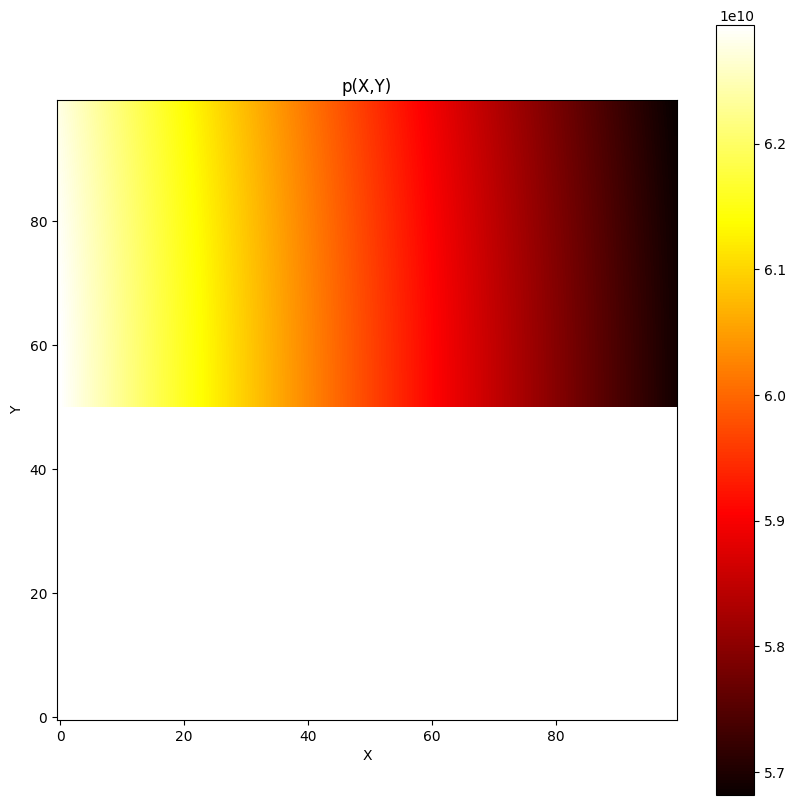

In [175]:
fig, ax = plt.subplots(figsize=[10,10])

# make im a pointer to the image
im = ax.imshow(P_XY,
          origin='lower',
          cmap='hot', 
          interpolation='bilinear'
          )


ax.set_xlabel('X')
ax.set_ylabel('Y')

ax.set_title('p(X,Y)')

# Create a colorbar using the im pointer
fig.colorbar(im)

plt.show()

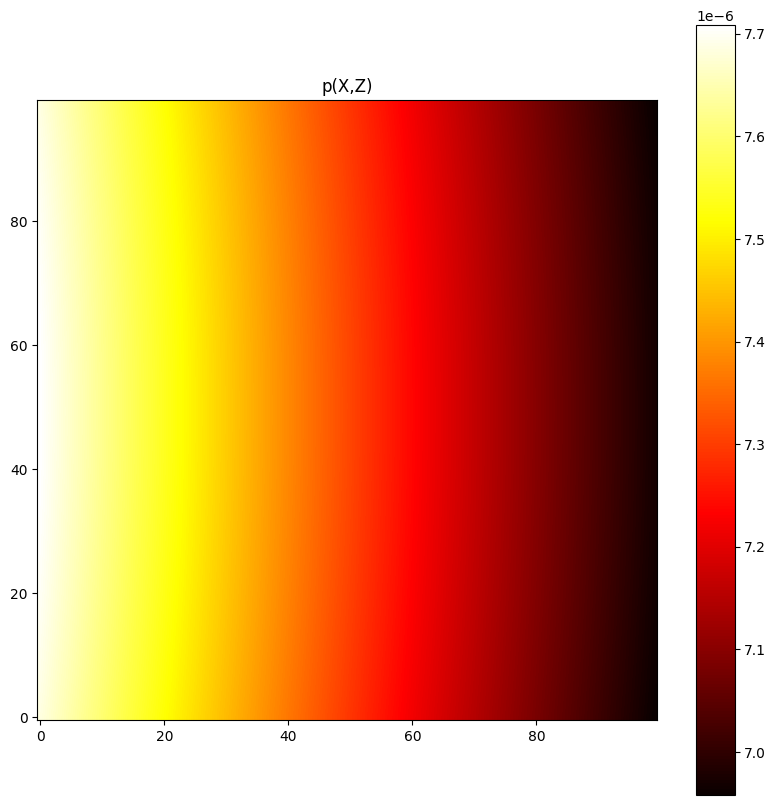

In [186]:
X = np.linspace(x_lim[0], x_lim[1], 100)
Z = np.linspace(z_lim[0], z_lim[1], 100)

X_malla, Z_malla = np.meshgrid(X, Y)
X_malla, Z_malla

P_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector + 0.1, vy=zero_vector, vz=zero_vector, mu=mu)
fig, ax = plt.subplots(figsize=[10,10])


im = ax.imshow(P_XZ,
          origin='lower',
          cmap='hot', 
          interpolation='bilinear'
          )

ax.set_title('p(X,Z)')

# Create a colorbar using the im pointer
fig.colorbar(im)

plt.show()

C:\Users\aguju\AppData\Local\Temp\ipykernel_44832\4006929283.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  det = 1.0/np.linalg.det(J)


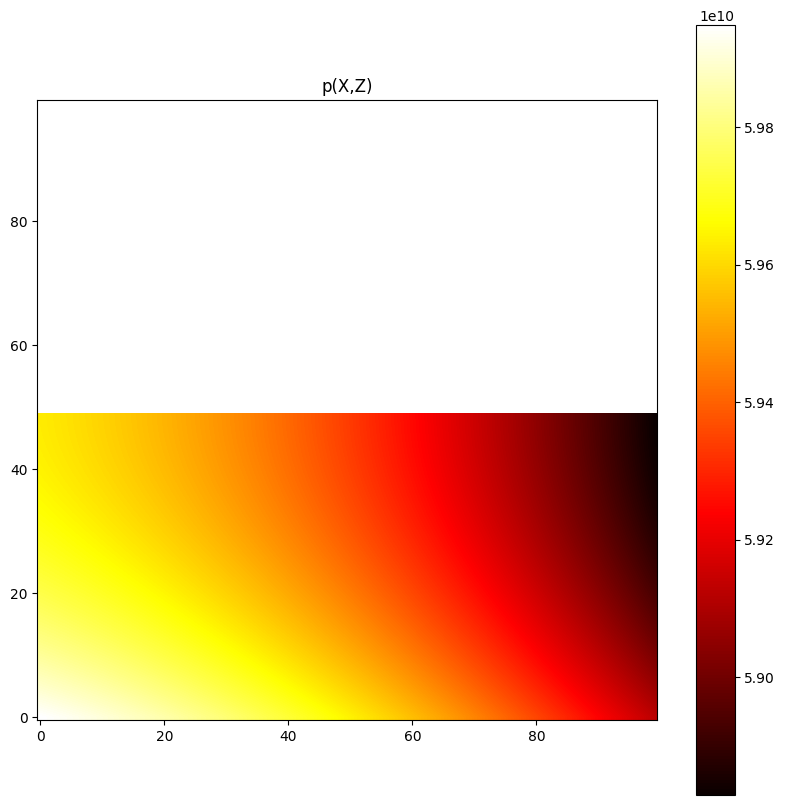

In [187]:
VX = np.linspace(vx_lim[0], vx_lim[1], 100)
VY = np.linspace(vy_lim[0], vy_lim[1], 100)

VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VY_malla

P_VX_VY = P_X_vectorized(x=zero_vector + 1, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
fig, ax = plt.subplots(figsize=[10,10])


im = ax.imshow(P_VX_VY,
          origin='lower',
          cmap='hot', 
          interpolation='bilinear'
          )

ax.set_title('p(X,Z)')

# Create a colorbar using the im pointer
fig.colorbar(im)

plt.show()